In [1]:
import pandas as pd
import matplotlib.pyplot as plt


tourney_df = pd.read_pickle('pickle/tourney_w_brackets_df.p')

In [2]:
win_df = tourney_df[['Winner', 'Probability']].groupby(['Winner']).sum()
win_df.sort_values(by='Probability', ascending=False, inplace=True)

win_df_nice = win_df.copy()
win_df_nice = win_df_nice.loc[win_df_nice['Probability'] > 0.05]
other = 1.0 - win_df_nice['Probability'].sum()
if other > 0.0001:
    win_df_nice.loc['Other'] = [other]

second_df = tourney_df[['Second', 'Probability']].groupby(['Second']).sum()
second_df.sort_values(by='Probability', ascending=False, inplace=True)

second_df_nice = second_df.copy()
second_df_nice = second_df_nice.loc[second_df_nice['Probability'] > 0.05]
other = 1.0 - second_df_nice['Probability'].sum()
if other > 0.0001:
    second_df_nice.loc['Other'] = [other]

third_df = tourney_df[['Third', 'Probability']].groupby(['Third']).sum()
third_df.sort_values(by='Probability', ascending=False, inplace=True)

third_df_nice = third_df.copy()
third_df_nice = third_df_nice.loc[third_df_nice['Probability'] > 0.05]
other = 1.0 - third_df_nice['Probability'].sum()
if other > 0.0001:
    third_df_nice.loc['Other'] = [other]


In [3]:
all_labels = set(win_df_nice.index) | set(second_df_nice.index) | set(third_df_nice.index)

In [4]:
def get_color_list(n, step, floor, start=0):
    ang = 2 * pi * step/n
    R = sqrt(1/3)
    k = 1 - floor
    coords = [[sqrt(6) / 3, R * cos(i * ang), R * sin(i * ang)] for i in range(n)]
    M = [[sqrt(3)/3, -sqrt(3)/3, -sqrt(3)/3],
         [sqrt(3)/3, (3+sqrt(3))/6, -(3-sqrt(3))/6],
         [sqrt(3)/3,  -(3-sqrt(3))/6, (3+sqrt(3))/6]]
    colors = []
    for xyz in coords:
        new = [floor + k * sum(a*b for a, b in zip(xyz, row)) for row in M]
        colors.append(new)
        # floor += (1 - floor) / n
        # k = 1 - floor
        x, y, z = xyz        
    return colors

In [5]:
from math import sin, cos, sqrt, gcd, pi

seen = set()
final_labels = []
for label in all_labels:
    if label not in seen:
        final_labels.append(label)
        seen.add(label)
        
for label in sorted(seen):
    print(label)
        
n = len(final_labels)
step = 1
while gcd(step, n) > 1:
    step += 1
floor = 0.5
colors = get_color_list(n, step, floor, start=0)
color_dict = {label: color for label, color in zip(final_labels, colors)}

color_dict

Bobby Ingram
Dan Wros
George Wright
Ian Thorpe
Justin Calvillo
Keith Schneider
Koy Kubasta
Nathan Sanches
Other
Patrick Commers
Serigne Diaw
Tyler Krause
none


{'Serigne Diaw': [0.5690355937288492, 0.9633731610262555, 0.6746980264314426],
 'George Wright': [0.5106723941126861, 0.9089447501090132, 0.7874896369648481],
 'Koy Kubasta': [0.5038608249580471, 0.8148285725967371, 0.888417383631763],
 'Nathan Sanches': [0.550161334669953, 0.7025855105345955, 0.954359935981999],
 'Justin Calvillo': [0.6389670344550359,
  0.5979290967654904,
  0.970210649966021],
 'Bobby Ingram': [0.7499336087172334, 0.5248348544374128, 0.9323383180319011],
 'Tyler Krause': [0.8576399525852647, 0.5000477935866136, 0.8494190350146691],
 'Ian Thorpe': [0.9374118406811174, 0.5292463311375449, 0.740448609367885],
 'Dan Wros': [0.9709744947974985, 0.6057414340178119, 0.630390852371237],
 'none': [0.9506391153501741, 0.7120089960234695, 0.5444586698129037],
 'Keith Schneider': [0.8810642927026378,
  0.8237043993619738,
  0.5023380891219358],
 'Patrick Commers': [0.7781887802559326,
  0.9152395732040051,
  0.5136784277266098],
 'Other': [0.6655801181272758, 0.9656449123407816

In [6]:
dfs = [win_df_nice, second_df_nice, third_df_nice]
disp_titles = ['1st Place', '2nd Place', '3rd Place']

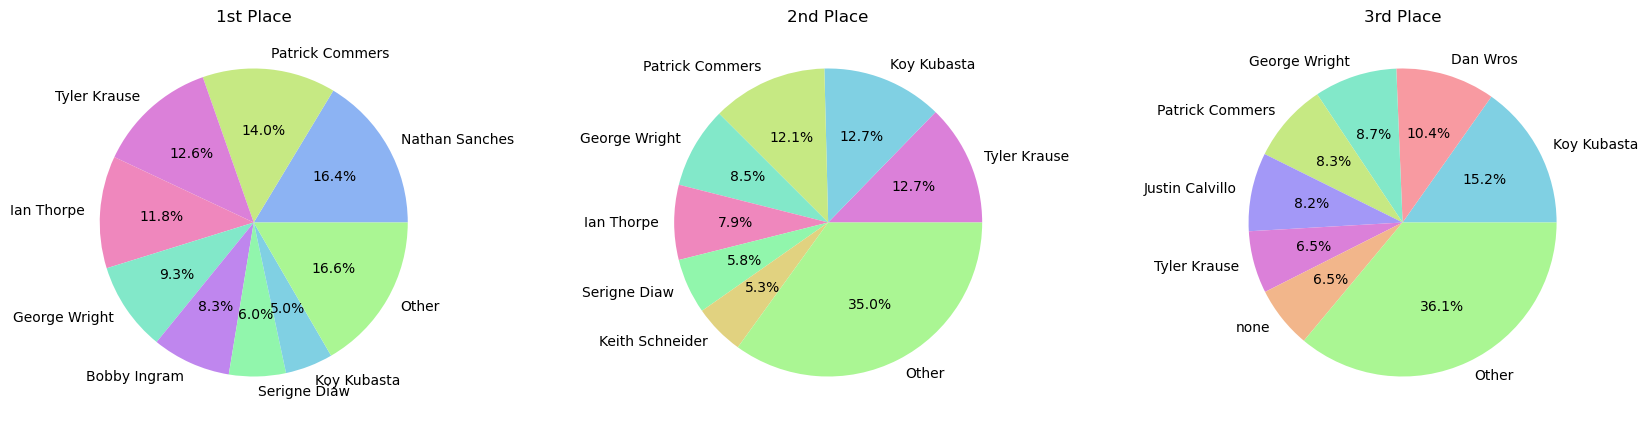

In [7]:
fig, axs = plt.subplots(1, 3, figsize = [21, 5])

for ax, title, df in zip(axs.flatten(), disp_titles, dfs):
    labels=df.index
    colors = [color_dict[label] for label in labels]
    labels = [_ for _ in labels]
    ax.pie(df['Probability'], 
           labels=labels,
           autopct='%1.1f%%',
           normalize=True,
           colors=colors)
    ax.set(ylabel='', title=title, aspect='equal')

plt.savefig('plots/win_place_show.png', dpi=300, bbox_inches='tight')

In [8]:
pot = 425.0
prizes = {
    1: 0.6 * pot,
    2: 0.3 * pot,
    3: .01 * pot
}

ev_dict = {}

for winner in win_df.index:
    winners = winner.split(', ')
    prob = win_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[1]
    elif nwinners == 2:
        total_prize = prizes[1] + prizes[2]
    else:
        total_prize = prizes[1] + prizes[2] + prizes[3]
    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in second_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = second_df.loc[winner, 'Probability']
    nwinners = len(winners)
    if nwinners == 1:
        total_prize = prizes[2]
    else:
        total_prize = prizes[2] + prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 

for winner in third_df.index:
    if winner == 'none':
        continue
    winners = winner.split(', ')
    prob = third_df.loc[winner, 'Probability']
    nwinners = len(winners)
    total_prize = prizes[3]

    share = prob * total_prize / nwinners
    for name in winners:
        if name not in ev_dict:
            ev_dict[name] = 0
        ev_dict[name] += share 
# ev_dict

ev_df = pd.DataFrame.from_dict(data=ev_dict, orient='index', columns=['EV (USD)'])
ev_df.sort_values(by='EV (USD)', ascending=False, inplace=True)
ev_df['EV (GBP)'] = ev_df['EV (USD)']  * 0.75
ev_df
    

,EV (USD),EV (GBP)
Patrick Commers,53.005826,39.754369
Tyler Krause,50.675532,38.006649
Nathan Sanches,44.962160,33.721620
Ian Thorpe,41.517924,31.138443
George Wright,36.605109,27.453832
Koy Kubasta,29.936890,22.452667
Bobby Ingram,27.606937,20.705203
Serigne Diaw,24.757507,18.568130
Keith Schneider,18.714602,14.035951
Mark Hurst,17.525248,13.143936


In [9]:
from IPython.display import display

display(ev_df.style.format({
    'EV (USD)': '${:,.2f}',
    'EV (GBP)': '£{:,.2f}' # Example for a different currency without decimals
}))



,EV (USD),EV (GBP)
Patrick Commers,$53.01,£39.75
Tyler Krause,$50.68,£38.01
Nathan Sanches,$44.96,£33.72
Ian Thorpe,$41.52,£31.14
George Wright,$36.61,£27.45
Koy Kubasta,$29.94,£22.45
Bobby Ingram,$27.61,£20.71
Serigne Diaw,$24.76,£18.57
Keith Schneider,$18.71,£14.04
Mark Hurst,$17.53,£13.14


In [10]:
pd.set_option('display.max_colwidth', 70)
print(win_df)

                                                          Probability
Winner                                                               
Nathan Sanches                                               0.163619
Patrick Commers                                              0.140068
Tyler Krause                                                 0.126473
Ian Thorpe                                                   0.117852
George Wright                                                0.093397
Bobby Ingram                                                 0.082649
Serigne Diaw                                                 0.059597
Koy Kubasta                                                  0.050107
Keith Schneider                                              0.035085
Mark Hurst                                                   0.034453
Dan Wros                                                     0.033729
Danny Ryan                                                   0.020336
Justin Calvillo     

In [11]:
pd.set_option('display.max_colwidth', 70)
print(second_df)

                                                                      Probability
Second                                                                           
Tyler Krause                                                             0.127232
Koy Kubasta                                                              0.126707
Patrick Commers                                                          0.121147
George Wright                                                            0.085480
Ian Thorpe                                                               0.078608
Serigne Diaw                                                             0.058030
Keith Schneider                                                          0.053075
Mark Hurst                                                               0.048159
Danny Ryan                                                               0.047562
Dan Wros                                                                 0.046046
Justin Calvillo 

In [12]:
pd.set_option('display.max_colwidth', 70)
print(third_df)

                                                                      Probability
Third                                                                            
Koy Kubasta                                                              0.152176
Dan Wros                                                                 0.104325
George Wright                                                            0.087040
Patrick Commers                                                          0.083164
Justin Calvillo                                                          0.082375
Tyler Krause                                                             0.065352
none                                                                     0.064878
Serigne Diaw                                                             0.049492
Keith Schneider                                                          0.046129
Danny Ryan                                                               0.044722
Mark Hurst      